# Zomato Restaurant Data Analysis using Python (EDA)

## Introduction

Zomato is one of India's largest food delivery and restaurant discovery platforms,
operating across 800+ cities with millions of active users. It allows customers to
discover restaurants, read reviews, order food online, and book tables — all from
one platform.

This project performs an in-depth Exploratory Data Analysis (EDA) on the
Zomato Bangalore Restaurant Dataset — one of the most competitive and diverse
food markets in India. Bangalore, known as the Silicon Valley of India, has a
massive and diverse food culture driven by its large tech workforce, student
population, and migrant professionals from across the country.

The dataset contains 51,169 restaurant records across 93 unique locations in
Bangalore, with 17 features covering restaurant names, ratings, votes, cuisines,
location, restaurant type, cost for two, online ordering availability,
and table booking availability.

The goal of this analysis is to uncover hidden patterns and trends in the
restaurant industry — understanding what drives customer ratings, which locations
dominate, what cuisines are most popular, and how pricing and services like online
ordering or table booking relate to customer satisfaction.

Tools Used:
- Python — core programming language
- Pandas — data loading, cleaning, and manipulation
- NumPy — numerical operations and missing value handling
- Matplotlib — base visualizations
- Seaborn — advanced statistical visualizations
- Google Colab — development environment

In [1]:
import os

if os.path.exists("/content/drive"):
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive Mounted")
else:
    print("Running Locally — No Drive Mount Needed")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive Mounted


## Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%matplotlib inline
sns.set_style("whitegrid")

- pandas - Used for data manipulation and analysis.
- numpy - Used for numerical operations.
- matplotlib.pyplot - Used for data visualization and plotting graphs.
- seaborn - Used for advanced statistical visualizations.
- %matplotlib inline- Displays plots directly
- sns.set_style("whitegrid") - Adds a white grid background to charts for better readability.

## Loading Dataset

In [4]:
import os

if os.path.exists("/content/drive/MyDrive/PROJECTS/zomato_Clean.csv"):
    df = pd.read_csv(
        "/content/drive/MyDrive/PROJECTS/zomato_Clean.csv",
        encoding='utf-8'
    )
    print("Loaded from Google Drive")

else:
    df = pd.read_csv(
        "zomato.csv",
        encoding='latin1',
        engine='python',
        on_bad_lines='skip'
    )
    print("Loaded from local file")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df

Loaded from Google Drive
Rows: 51118
Columns: 17


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51113,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51114,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51115,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51116,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


#### Information Derived
- Dataset loaded successfully into a DataFrame named 'df'.
- Total records: 51,118 rows and 17 columns.
- Columns include: url, address, name, online_order, book_table, rate, votes, phone, location, rest_type, dish_liked, cuisines, approx_cost(for two people), reviews_list, menu_item, listed_in(type), listed_in(city).

## First Five Rows

The `head()` function is used to display the first five rows of the dataset.

In [5]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


#### Information Derived
- Displays the first 5 rows for a quick visual inspection of the data.
- Confirms column names and values loaded correctly.
- Reveals that the 'rate' column stores values in '4.1/5' string format — requires cleaning before analysis.
- The 'approx_cost' column contains commas (e.g., '1,000') — also needs cleaning.
- The 'url' and 'address' columns are visible here and will be dropped later as they are not useful for analysis.

## Last Five Rows

The `tail()` function is used to display the last five rows of the dataset.

In [6]:
df.tail()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
51113,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51114,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51115,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51116,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield
51117,https://www.zomato.com/bangalore/the-nest-the-...,"ITPL Main Road, KIADB Export Promotion Industr...",The Nest - The Den Bengaluru,No,No,3.4 /5,13,+91 8071117272,"ITPL Main Road, Whitefield","Bar, Casual Dining",NaN,"Finger Food, North Indian, Continental","1,500","[('Rated 5.0', 'RATED\n Great ambience , look...",[],Pubs and bars,Whitefield


#### Information Derived
- Displays the last 5 rows to verify the dataset was fully loaded without truncation.
- Confirms no abrupt ending or trailing empty rows in the file.
- Verifies consistent column structure throughout the entire dataset.

## Shape of Dataset

The `shape` function helps determine the number of rows and columns in the dataset.

In [7]:
df.shape

(51118, 17)

#### Information Derived
- Output: (51118, 17) — 51,118 rows and 17 columns.
- This is a large dataset with over 51K restaurant records from Bangalore.
- 17 features provide a rich mix of categorical and numerical data for multi-dimensional analysis.

## Column Names

The `columns` function displays all available features in the dataset.

In [8]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

#### Information Derived
- Dataset has 17 columns: url, address, name, online_order, book_table, rate, votes, phone, location, rest_type, dish_liked, cuisines, approx_cost(for two people), reviews_list, menu_item, listed_in(type), listed_in(city).


## Dataset Information

The `info()` function provides information about data types, column names, and non-null values.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51118 entries, 0 to 51117
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51118 non-null  object
 1   address                      51118 non-null  object
 2   name                         51118 non-null  object
 3   online_order                 51118 non-null  object
 4   book_table                   51118 non-null  object
 5   rate                         43343 non-null  object
 6   votes                        51118 non-null  int64 
 7   phone                        49915 non-null  object
 8   location                     51097 non-null  object
 9   rest_type                    50894 non-null  object
 10  dish_liked                   23044 non-null  object
 11  cuisines                     51073 non-null  object
 12  approx_cost(for two people)  50774 non-null  object
 13  reviews_list                 51

#### Information Derived
- Most columns are stored as 'object' (string) dtype — only 'votes' is int64.
- 'rate' and 'approx_cost(for two people)' are strings and need type conversion before analysis.
- dish_liked has the most missing values: 28074 out of 51,118 (54.9% missing).
- online_order, book_table, votes, name: all 51,118 non-null — completely filled columns.

## Statistical Summary

The `describe()` function provides summary statistics for numerical columns.

In [10]:
df.describe()

,votes
count,51118.000000
mean,258.853672
std,705.856306
min,0.000000
25%,6.000000
50%,39.000000
75%,188.000000
max,16832.000000


#### Information Derived
- Before cleaning, only 'votes' appears in describe() as it is the only numeric column.
- votes: mean = 258.85, min = 0, max = 16,832 — extreme right skew;
  a few restaurants have very high engagement.
- 25th percentile = 6 votes, median = 39 votes, 75th percentile = 188 votes —
  most restaurants have very few reviews.


## Checking Datatypes

The `dtypes` function helps identify the datatype of each column.

In [11]:
df.dtypes

,0
url,object
address,object
name,object
online_order,object
book_table,object
rate,object
votes,int64
phone,object
location,object
rest_type,object


#### Information Derived
- All columns except 'votes' are stored as 'object' (string) dtype.
- 'rate' must be converted to float after removing '/5' suffix.
- 'approx_cost(for two people)' must be converted to float after removing commas.
- 'online_order' and 'book_table' are binary Yes/No strings —
  converted to 0/1 via label encoding later.

## Checking Missing Values

This function identifies missing or null values in each column.

In [12]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1203
location,21
rest_type,224


#### Information Derived
- dish_liked: 28,074 missing (54.9%) — largest gap in the dataset.
- rate: 7,778 missing.
- approx_cost(for two people): 345 missing.
- rest_type: 224 missing | cuisines: 45 missing | location: 21 missing.
- online_order, book_table, votes, name: 0 missing — fully complete columns.

## Checking Duplicate Records

The `duplicated()` function checks repeated restaurant records.

In [13]:
df.duplicated().sum()

np.int64(0)

#### Information Derived
- Output: 0 — the dataset contains no fully duplicate rows.
- All 51,118 records are unique entries.

## Checking Unique Values


The `nunique()` function identifies the number of unique values in each column.

In [14]:
df.nunique()

,0
url,51118
address,11484
name,8783
online_order,2
book_table,2
rate,64
votes,2227
phone,14886
location,93
rest_type,93


#### Information Derived
- name: 8,783 unique restaurant names — same restaurant appears across multiple locations.
- online_order and book_table: 2 unique values each (Yes/No).
- location: 93 unique areas in Bangalore.
- rest_type: 93 unique restaurant type combinations.
- cuisines: 2,715 unique cuisine combinations.
- approx_cost: 70 unique price points.
- listed_in(type): 7 listing categories | listed_in(city): 30 unique city zones.

## Checking Dataset Before Cleaning

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51118 entries, 0 to 51117
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51118 non-null  object
 1   address                      51118 non-null  object
 2   name                         51118 non-null  object
 3   online_order                 51118 non-null  object
 4   book_table                   51118 non-null  object
 5   rate                         43343 non-null  object
 6   votes                        51118 non-null  int64 
 7   phone                        49915 non-null  object
 8   location                     51097 non-null  object
 9   rest_type                    50894 non-null  object
 10  dish_liked                   23044 non-null  object
 11  cuisines                     51073 non-null  object
 12  approx_cost(for two people)  50774 non-null  object
 13  reviews_list                 51

#### Information Derived
- Sorted missing values confirm dish_liked (28,074) is the most incomplete column.
- Rate has 7,778 missing values — will be filled with median (3.7) after cleaning.
- Columns with zero missing: name, online_order, book_table, votes,
  reviews_list, menu_item, listed_in(type), listed_in(city).


## Checking Missing Values in Detail

In [16]:
df.isnull().sum().sort_values(ascending=False)

,0
dish_liked,28074
rate,7775
phone,1203
approx_cost(for two people),344
rest_type,224
cuisines,45
location,21
url,0
address,0
votes,0


#### Information Derived
This sorted view helps prioritize which columns need cleaning before analysis.

### Checking Rating Column Unique Values

In [17]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '2.4 /5', '4.7 /5',
       '2.2 /5', '2.0 /5', '2.1 /5', '1.8 /5'], dtype=object)

#### Information Derived
- Rating values are stored as strings in '4.1/5' format.
- Special non-numeric entries found: 'NEW' (newly listed restaurants with no rating)
  and '-' (no rating available).
- Valid rating range: 1.8 to 4.9 — all stored as strings before cleaning.
- This confirms the need to replace 'NEW' and '-' with NaN,
  remove '/5', and convert to float.

### Cleaning Rating Column

In [18]:
df['rate'] = df['rate'].replace('NEW', np.nan)
df['rate'] = df['rate'].replace('-', np.nan)

#### Information Derived
- 'NEW' entries replaced with NaN — newly listed restaurants with no customer ratings yet.
- '-' entries replaced with NaN — missing or unavailable rating data.


### Remove '/5' From Ratings

In [19]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

#### Information Derived
- '/5' suffix removed from all values (e.g., '4.1/5' becomes '4.1').

### Convert Rating into Float

In [20]:
df['rate'] = df['rate'].astype(float)

#### Information Derived
- Column successfully converted to float dtype.

In [21]:
df['rate'].dtype

dtype('float64')

### Check Approximate Cost Column

In [22]:
df['approx_cost(for two people)'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', nan, '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

#### Information Derived
- Commas were present in values like '1,200' making them non-numeric strings.


### Remove Comma from Cost Column

In [23]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')

### Converting Cost Column to Float

In [24]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)

In [25]:
df['approx_cost(for two people)'].dtype

dtype('float64')

#### Information Derived
- After removing commas and converting to float: cost range is ₹40 to ₹6,000.


 ### Missing Value

In [26]:
df['rate'] = df['rate'].fillna(df['rate'].median())

In [27]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,0
votes,0
phone,1203
location,21
rest_type,224


#### Information Derived
- Missing rate values filled using the median value of 3.7.
- Median chosen over mean because it is robust to extreme outlier ratings.
- Preserves all 51,118 rows instead of dropping incomplete records.
- After filling: rate column has 0 missing values — fully complete for analysis.

### Removing Unnecessary Columns

In [28]:
df.drop(['url', 'address'], axis=1, inplace=True)

In [29]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'phone',
       'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

#### Information Derived
- 'url' dropped — contains only Zomato webpage links, not useful for business analysis.
- 'address' dropped — 'location' column already provides area-level data sufficient for analysis.
- Dataset reduced from 17 to 15 columns — cleaner and more focused DataFrame.

### Label Encoding

In [30]:
df['online_order_enc'] = df['online_order'].map({'Yes': 1, 'No': 0})
df['book_table_enc'] = df['book_table'].map({'Yes': 1, 'No': 0})

In [31]:
df.head()

,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),online_order_enc,book_table_enc
0,Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,1,1
1,Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,1,0
2,San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,1,0
3,Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,0,0
4,Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,0,0


#### Information Derived
- `online_order`: Yes - 1, No - 0.
- `book_table`: Yes - 1, No - 0.
- These new numeric columns are now usable in the correlation heatmap.


## Cost Outlier Detection

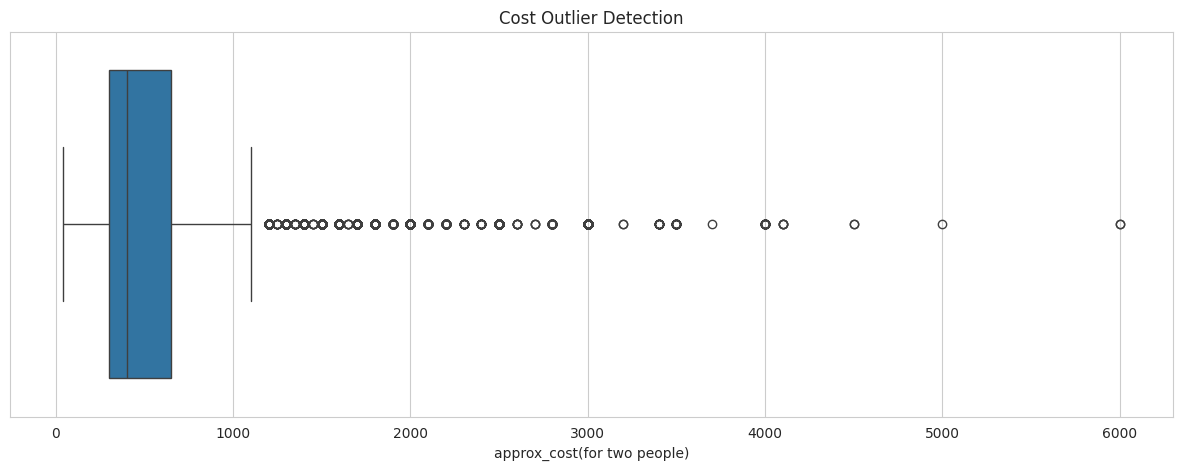

In [32]:
plt.figure(figsize=(15,5))
sns.boxplot(x=df['approx_cost(for two people)'])

plt.title("Cost Outlier Detection")
plt.show()

#### Information Derieved
- The boxplot is used to detect outliers
in restaurant pricing.
- Most restaurants fall within affordable price ranges.
- Some restaurants show extremely high costs and appear as outliers representing premium dining segments.
- This indicates large variation
in restaurant pricing.


## Online Order Analysis

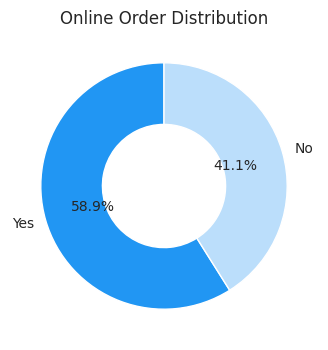

In [33]:
online_order_counts = df['online_order'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    online_order_counts,
    labels=online_order_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2196F3', '#BBDEFB'],
    wedgeprops={'width':0.5}
)

plt.title("Online Order Distribution")

plt.show()

#### Information Derived
- Yes (online ordering available):58.9% of total.
- No (not available):41.1% of total.
- The donut chart clearly shows that majority of Bangalore restaurants
  support online ordering, reflecting the city's strong delivery culture.
- Nearly 6 out of 10 restaurants on Zomato offer online ordering —
  confirming that food delivery is the dominant business model in Bangalore.
- Restaurants without online ordering are likely dine-in focused
  or premium establishments that prefer walk-in customers.
  

## Table Booking Analysis

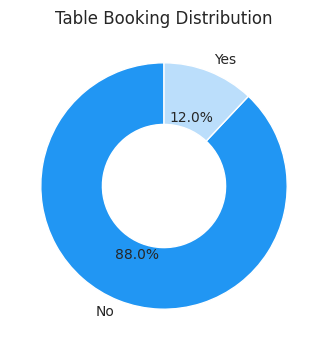

In [34]:
table_booking = df['book_table'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    table_booking.values,
    labels=table_booking.index,
    colors=['#2196F3', '#BBDEFB'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.5}
)

plt.title("Table Booking Distribution")

plt.show()

#### Information Derived
- No (table booking unavailable): 88.0% of total.
- Yes (table booking available): 12.0% of total.
- The donut chart makes the imbalance immediately visible —
  only 1 in 8 restaurants offers table booking.
- Table booking is a premium, minority feature exclusive to fine dining
  and high-end casual dining establishments.
- Bangalore's food scene is dominated by quick service, cafes, and
  delivery-focused outlets that don't require advance reservations.

## Rating Distribution

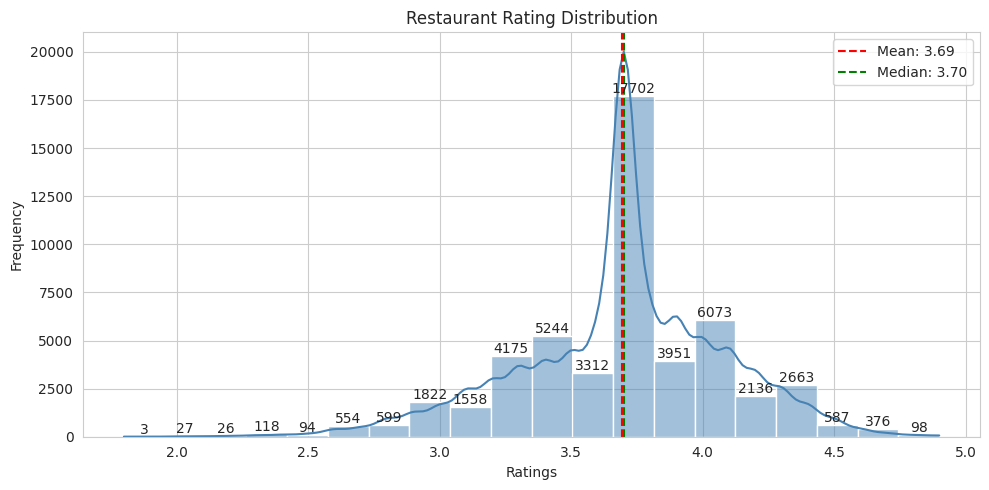

In [35]:

plt.figure(figsize=(10, 5))

num = sns.histplot(df['rate'], bins=20, kde=True, color='steelblue')

for container in num.containers:
    num.bar_label(container)

plt.axvline(df['rate'].mean(), color='red', linestyle='--', label=f"Mean: {df['rate'].mean():.2f}")
plt.axvline(df['rate'].median(), color='green', linestyle='--', label=f"Median: {df['rate'].median():.2f}")

plt.title("Restaurant Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

#### Information Derived
- Ratings range from 1.8 to 4.9 on a 5-point scale.
- Mean rating: 3.69 (red dashed line) | Median: 3.70 (green dashed line).
- Mean and median are nearly identical — distribution is symmetric with no significant skew.
- The KDE curve shows a smooth bell shape peaking between 3.5–4.0.
- Very few restaurants fall below 2.5 or above 4.8 — rare outliers at both ends.

## Top 10 Restaurant Locations

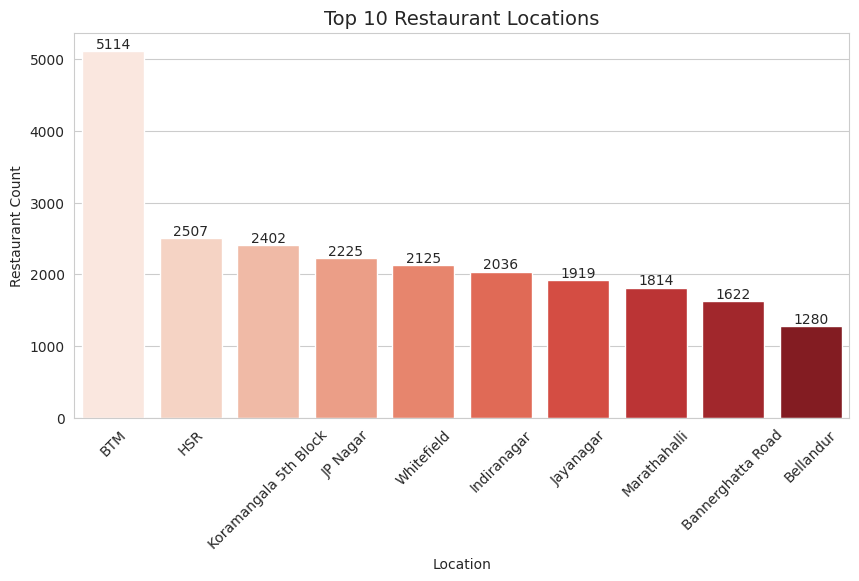

In [36]:
top_location = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))

num = sns.barplot(x=top_location.index, y=top_location.values, hue=top_location.index, palette='Reds', legend=False)

for container in num.containers:
    num.bar_label(container)

plt.title("Top 10 Restaurant Locations", fontsize=14)
plt.xlabel("Location")
plt.ylabel("Restaurant Count")
plt.xticks(rotation=45)
plt.show()

#### Information Derived
- BTM: 5,114 restaurants — the most restaurant-dense area in Bangalore.
- HSR: 2,507 | Koramangala 5th Block: 2,402 | JP Nagar: 2,225 | Whitefield: 2,125.
- Indiranagar: 2,036 | Jayanagar: 1,919 | Marathahalli: 1,814 |
  Bannerghatta Road: 1,622 | Bellandur: 1,280.
- BTM alone accounts for roughly 10% of all restaurant listings in the dataset.


## Top Restaurant Types

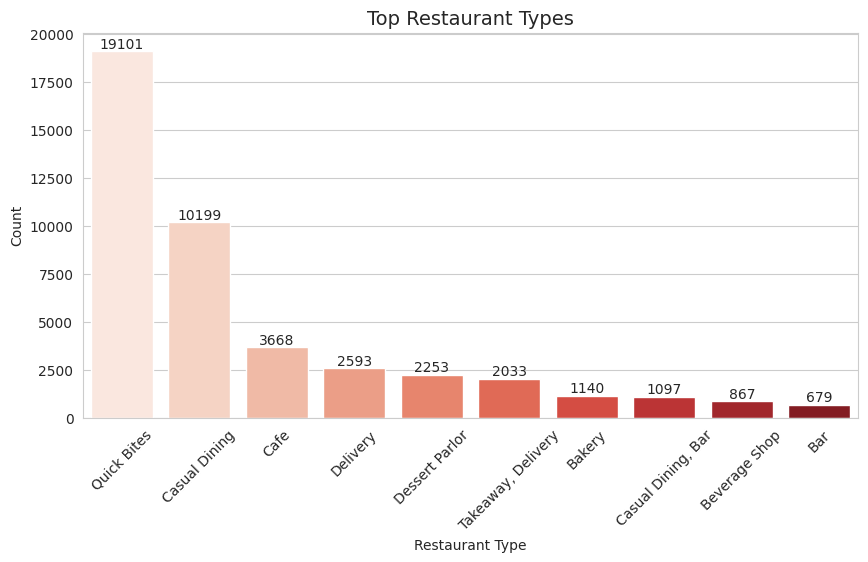

In [37]:
top_rest = df['rest_type'].value_counts().head(10)

plt.figure(figsize=(10,5))

num = sns.barplot(x=top_rest.index, y=top_rest.values, hue=top_rest.index, palette='Reds', legend=False)

for container in num.containers:
    num.bar_label(container)

plt.title("Top Restaurant Types", fontsize=14)
plt.xlabel("Restaurant Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Information Derived
- Quick Bites: 19,102 (37.3%) — most dominant restaurant type.
- Casual Dining: 10,199 (19.9%) — second most common.
- Cafe: 3,668 | Delivery: 2,593 | Dessert Parlor: 2,253 | Takeaway, Delivery: 2,033.
- Bakery: 1,140 | Casual Dining, Bar: 1,097 | Beverage Shop: 867 | Bar: 679.
- Over 57% of restaurants are Quick Bites or Casual Dining.
- Bangalore diners prefer convenient, fast, casual eating experiences.

## Cost Distribution

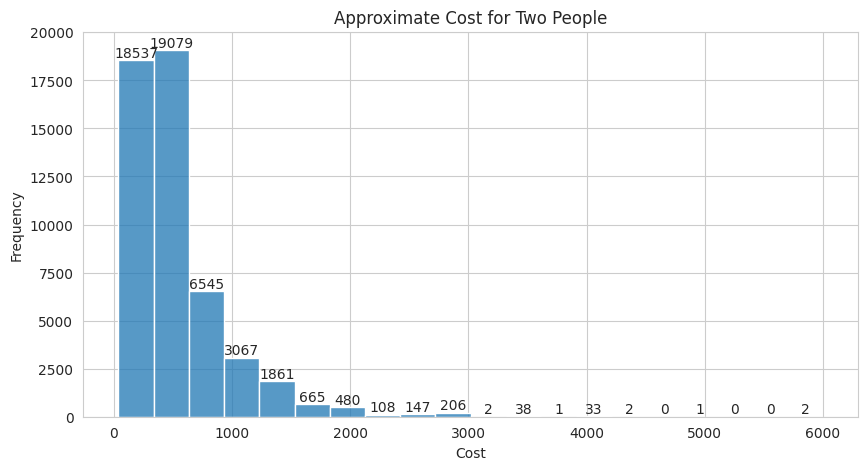

In [38]:
plt.figure(figsize=(10,5))

num = sns.histplot(df['approx_cost(for two people)'], bins=20)

for container in num.containers:
    num.bar_label(container)

plt.title("Approximate Cost for Two People")
plt.xlabel("Cost")
plt.ylabel("Frequency")
plt.show()

In [39]:
df['approx_cost(for two people)'].describe()

,approx_cost(for two people)
count,50774.000000
mean,548.930063
std,433.787837
min,40.000000
25%,300.000000
50%,400.000000
75%,650.000000
max,6000.000000


#### Information Derived
- Cost range: ₹40 (minimum) to ₹6,000 (maximum) for two people.
- Distribution is strongly right-skewed - majority fall in the ₹200–₹600 range.
- Mean: ₹548.93 | Median: ₹400 - median is lower due to many budget restaurants.
- 25th percentile: ₹300 | 75th percentile: ₹650.
- Bangalore's food scene is largely budget-to-mid-range,
  catering to working professionals and students.


## Top 10 Cuisines

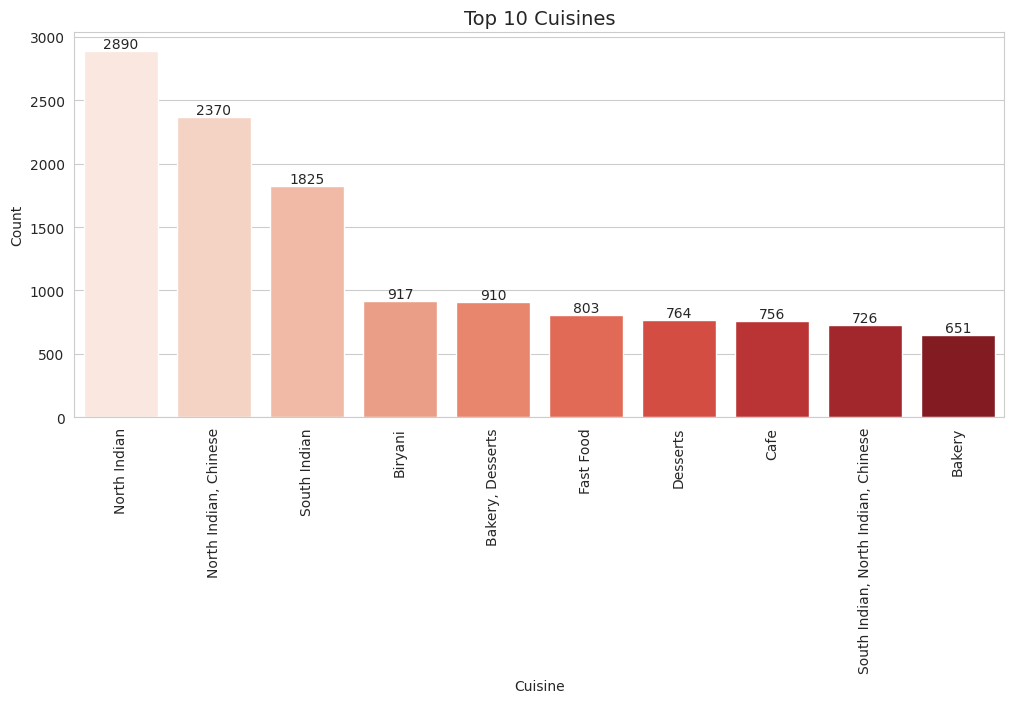

In [40]:
top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(12,5))

num = sns.barplot( x=top_cuisines.index, y=top_cuisines.values, hue=top_cuisines.index, palette='Reds', legend=False)

for container in num.containers:
    num.bar_label(container)

plt.title("Top 10 Cuisines", fontsize=14)
plt.xlabel("Cuisine")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

#### Information Derived
- North Indian: 2,890 — most popular single cuisine in Bangalore.
- North Indian, Chinese: 2,370 — most popular combination (Indo-Chinese trend).
- South Indian: 1,825 | Biryani: 917 | Bakery, Desserts: 910 | Fast Food: 803.
- Cafe: 756 | Desserts: 764 | South Indian, North Indian, Chinese: 726 | Bakery: 651.
- North Indian dominates despite Bangalore being a South Indian city — driven by the large migrant workforce from North India.

## Online Order vs Rating

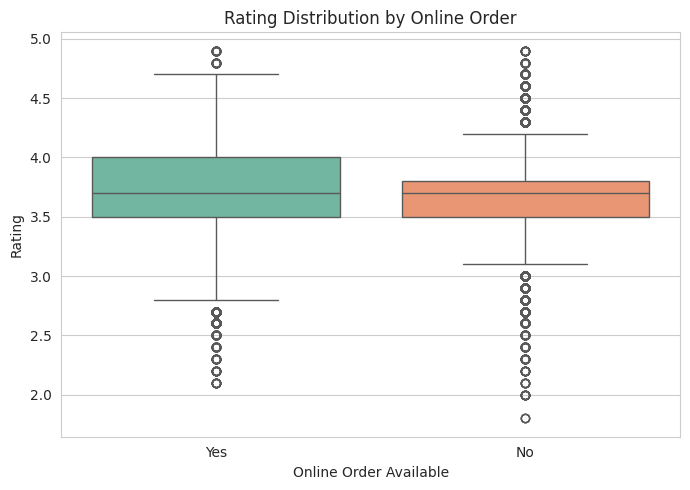

In [41]:
plt.figure(figsize=(7, 5))

sns.boxplot(x='online_order',y='rate',data=df, hue='online_order', palette='Set2',legend=False)

plt.title("Rating Distribution by Online Order")
plt.xlabel("Online Order Available")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

In [42]:
df['rate'].describe()

,rate
count,51118.000000
mean,3.694880
std,0.389751
min,1.800000
25%,3.500000
50%,3.700000
75%,3.900000
max,4.900000


#### Information Derived
- Online Order = Yes: Mean rating 3.7 | Median 3.7.
- Online Order = No: Mean rating 3.67 | Median 3.7.
- Median is identical for both groups (3.7) — difference only exists in the tails.
- Mean difference of only 0.05 points confirms online ordering is NOT a major driver of customer ratings.
- Business insight: Adding online ordering alone will not meaningfully boost a restaurant's rating.

## Table Booking vs Rating

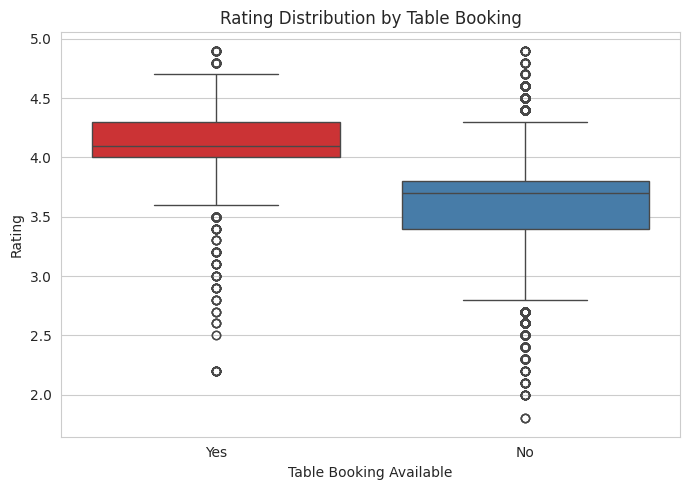

In [43]:
plt.figure(figsize=(7, 5))

sns.boxplot(x='book_table', y='rate', data=df, hue='book_table', palette='Set1', legend=False)

plt.title("Rating Distribution by Table Booking")
plt.xlabel("Table Booking Available")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

In [44]:
df.groupby('book_table')['rate'].agg(['mean', 'median'])

,mean,median
book_table,,
No,3.636852,3.7
Yes,4.120121,4.1


In [45]:
avg_rating = df.groupby('book_table')['rate'].mean()
gap = avg_rating['Yes'] - avg_rating['No']
print(gap)

0.4832686262501662


#### Information Derived
- Table Booking = Yes: Mean rating 4.12 | Median 4.1 — consistently high.
- Table Booking = No: Mean rating 3.64 | Median 3.7 — lower with wider spread.
- The 0.48 point mean gap is the strongest rating difference found in this entire dataset.
- Table booking restaurants are premium dining establishments with higher service quality.
- Business insight: Investing in the full dining experience drives customer satisfaction far more than delivery convenience.

## Votes vs Rating

/tmp/ipykernel_59286/4114927036.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg = df.groupby('vote_tier')['rate'].mean()
/tmp/ipykernel_59286/4114927036.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  num = sns.barplot(x=avg.index, y=avg.values, palette='Reds')


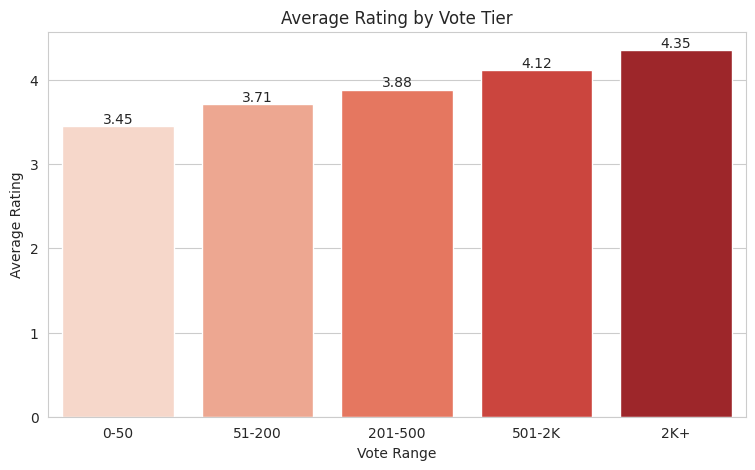

In [46]:
df['vote_tier'] = pd.cut(df['votes'], bins=[0, 50, 200, 500, 2000, 20000],
                         labels=['0-50', '51-200', '201-500', '501-2K', '2K+'])

avg = df.groupby('vote_tier')['rate'].mean()

plt.figure(figsize=(9,5))

num = sns.barplot(x=avg.index, y=avg.values, palette='Reds')

for container in num.containers:
    num.bar_label(container, fmt='%.2f')

plt.title("Average Rating by Vote Tier")
plt.xlabel("Vote Range")
plt.ylabel("Average Rating")
plt.show()

#### Information Derived
- 0-50 votes: avg rating 3.45 — lowest engagement, most unpredictable quality.
- 51-200 votes: avg rating 3.71 | 201-500 votes: avg rating 3.88.
- 501-2K votes: avg rating 4.12 | 2K+ votes: avg rating 4.35 — highest quality tier.
- There is a clear, consistent upward trend — every vote tier has a
  higher average rating than the tier below it.
- Restaurants with 2,000+ votes average 4.35 — nearly a full point higher
  than restaurants with under 50 votes (3.45).
- This confirms that customer engagement (votes) and quality (rating) are
  strongly linked — popular restaurants maintain high ratings over time.
- High-vote restaurants have likely survived longer on the platform because
  of consistently good food and service — low-quality restaurants
  lose customers and votes quickly.
- Business insight: focus on building reviews and engagement early —
  more votes leads to higher perceived quality.

## Cost vs Rating

/tmp/ipykernel_59286/4237584876.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  num = sns.barplot(x=avg.index, y=avg.values, palette='Reds')


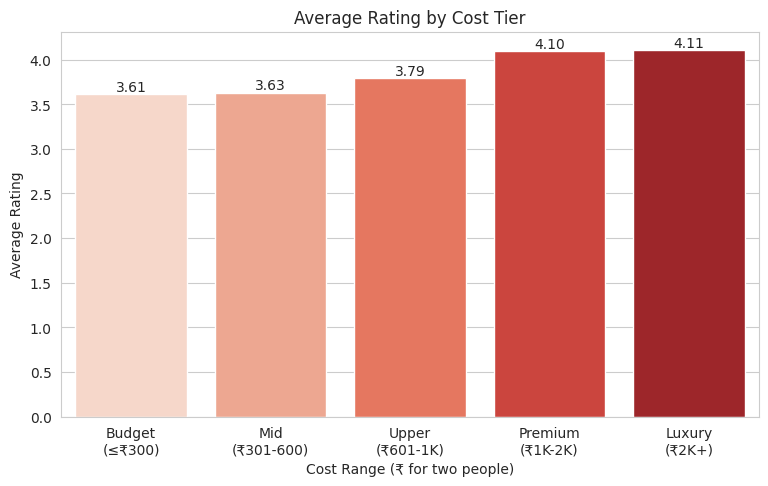

In [47]:
bins = [0, 300, 600, 1000, 2000, 6000]
labels = ['Budget\n(≤₹300)', 'Mid\n(₹301-600)',
          'Upper\n(₹601-1K)', 'Premium\n(₹1K-2K)', 'Luxury\n(₹2K+)']

df['cost_tier'] = pd.cut(df['approx_cost(for two people)'], bins=bins, labels=labels)

avg = df.groupby('cost_tier', observed=True)['rate'].mean().round(2)

plt.figure(figsize=(9, 5))

num = sns.barplot(x=avg.index, y=avg.values, palette='Reds')

for container in num.containers:
    num.bar_label(container, fmt='%.2f')

plt.title("Average Rating by Cost Tier")
plt.xlabel("Cost Range (₹ for two people)")
plt.ylabel("Average Rating")
plt.show()

#### Information Derived
- Budget (≤₹300): avg rating 3.61 - widest quality variance, most unpredictable.
- Mid (₹301-600): avg rating 3.63 | Upper (₹601-1K): avg rating 3.79.
- Premium (₹1K-2K): avg rating 4.10 | Luxury (₹2K+): avg rating 4.11 - highest quality tier.
- There is a clear and consistent upward trend across all 5 cost tiers -
  every price bracket has a higher average rating than the one below it.
- Luxury restaurants (₹2K+) average 4.11 — 0.50 points higher than budget restaurants (3.61)
- This confirms that price acts as a quality signal on Zomato -
  customers who pay more expect and receive better quality.
- The budget segment (≤₹300) has the lowest average rating because
  quality control is harder to maintain at very low price points.
- Business insight: if targeting high ratings, invest in quality ingredients,
  ambience, and service - and price accordingly.
  Cheap pricing alone does not win high ratings.

## Restaurant Type vs Rating

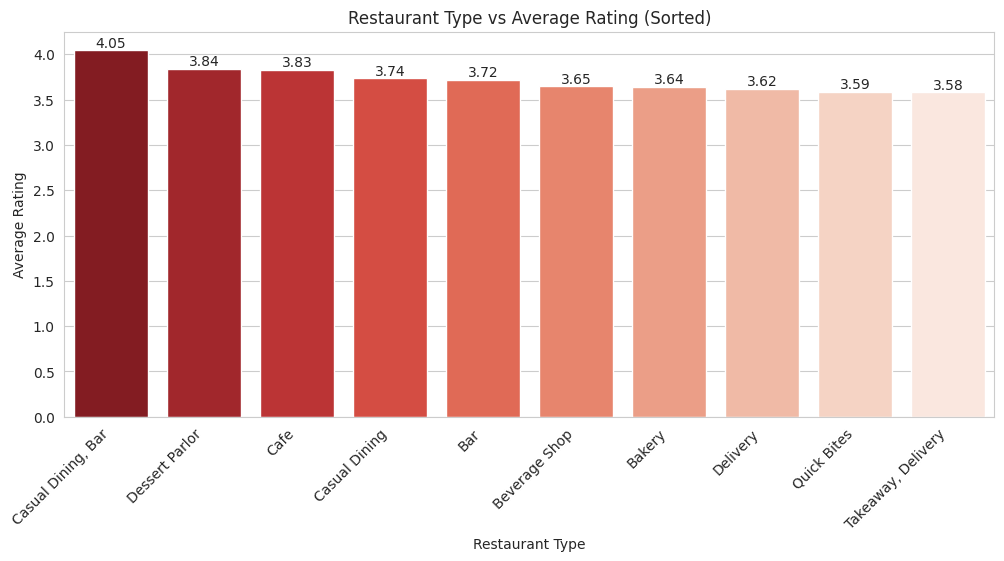

In [48]:
top_rest = df['rest_type'].value_counts().head(10).index
filtered_df = df[df['rest_type'].isin(top_rest)]

avg_by_type = filtered_df.groupby('rest_type')['rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))

num = sns.barplot(x=avg_by_type.index, y=avg_by_type.values, hue=avg_by_type.index, palette='Reds_r', legend=False)

for container in num.containers:
    num.bar_label(container, fmt='%.2f')

plt.title("Restaurant Type vs Average Rating (Sorted)")
plt.xlabel("Restaurant Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.show()

#### Information Derived
- Casual Dining, Bar: 4.05 — highest average rating among all top restaurant types.
- Dessert Parlor: 3.84 | Cafe: 3.83 | Casual Dining: 3.74 | Bar: 3.72.
- Beverage Shop: 3.65 | Bakery: 3.64 | Delivery: 3.62 |
  Quick Bites: 3.59 | Takeaway, Delivery: 3.58.
- Gap between highest (4.05) and lowest (3.58): 0.47 points — significant on a 5-point scale.
- Experience-driven types (Bar, Cafe, Casual Dining) consistently outperform
  convenience-driven types (Delivery, Takeaway, Quick Bites).

##Top 10 Expensive Restaurants

In [49]:
expensive_restaurants = df.drop_duplicates(subset='name').sort_values(by='approx_cost(for two people)',ascending=False)[['name', 'approx_cost(for two people)', 'rate']].head(10)
expensive_restaurants



,name,approx_cost(for two people),rate
19039,Le Cirque Signature - The Leela Palace,6000.0,4.3
39912,Royal Afghan - ITC Windsor,5000.0,4.3
41207,Malties - Radisson Blu,4500.0,4.3
37414,La Brasserie - Le Meridien,4100.0,4.1
6081,Alba - JW Marriott Bengaluru,4000.0,4.5
39923,Dum Pukht Jolly Nabobs - ITC Windsor,4000.0,4.3
6299,Grill 99 - The Ritz-Carlton,4000.0,3.5
19021,Jamavar - The Leela Palace,4000.0,4.2
39919,Dakshin - ITC Windsor,4000.0,4.3
6131,Riwaz - The Ritz-Carlton,4000.0,4.1


#### Information Derived
- Rank 1: Le Cirque Signature - The Leela Palace | ₹6,000 | Rating: 4.3
- Rank 2: Royal Afghan - ITC Windsor | ₹5,000 | Rating: 4.3
- Rank 3: Malties - Radisson Blu | ₹4,500 | Rating: 4.3
- Rank 4: La Brasserie - Le Meridien | ₹4,100 | Rating: 4.1
- Ranks 5-10 (all ₹4,000): Alba - JW Marriott (4.5), Dum Pukht Jolly Nabobs - ITC Windsor (4.3), Grill 99 - The Ritz-Carlton (3.5), Jamavar - The Leela Palace (4.2), Dakshin - ITC Windsor (4.3), Riwaz - The Ritz-Carlton (4.1).
- All top 10 are luxury hotel restaurants - hotel dining is the only segment reaching ₹4,000+.
- Average rating of top 10 most expensive restaurants: 4.24
- Premium price = Premium quality.

## Top 10 Most Reviewed Restaurants

In [50]:
most_reviewed = df.drop_duplicates(subset='name').sort_values(by='votes',ascending=False)[['name', 'votes', 'rate']].head(10)
most_reviewed

,name,votes,rate
3918,Byg Brewski Brewing Company,16345,4.9
19168,Toit,14956,4.7
19015,Big Pitcher,9041,4.7
5926,Arbor Brewing Company,8375,4.5
28164,Prost Brew Pub,7854,4.5
5243,Church Street Social,7544,4.3
4952,Hoot,7193,4.2
26397,The Hole in the Wall Cafe,7113,4.6
3759,The Black Pearl,7023,4.8
18549,Vapour Pub & Brewery,6907,4.2


#### Information Derived
- Rank 1: Byg Brewski Brewing Company | 16,345 votes | Rating: 4.9
- Rank 2: Toit | 14,956 votes | Rating: 4.7
- Rank 3: Big Pitcher | 9,041 votes | Rating: 4.7
- Rank 4: Arbor Brewing Company | 8,375 votes | Rating: 4.5
- Rank 5: Prost Brew Pub | 7,854 votes | Rating: 4.5
- Rank 6: Church Street Social | 7,544 votes | Rating: 4.3
- Rank 7: Hoot | 7,193 votes | Rating: 4.2
- Rank 8: The Hole in the Wall Cafe | 7,113 votes | Rating: 4.6
- Rank 9: The Black Pearl | 7,023 votes | Rating: 4.8
- Rank 10: Vapour Pub & Brewery | 6,907 votes | Rating: 4.2
- 7 out of 10 most reviewed are brewpubs or bars
- Bangalore's brewery culture dominates customer engagement.
- All top 10 have ratings above 4.2 — most reviewed = consistently best rated.

## Correlation Heatmap

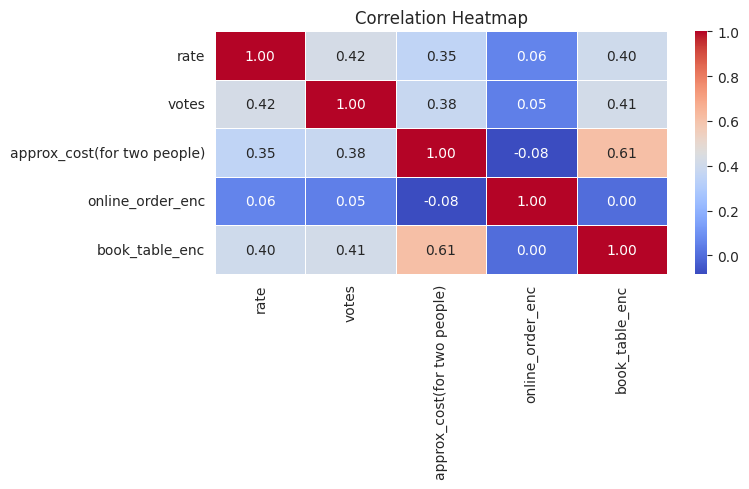

In [51]:
plt.figure(figsize=(8, 5))

cols = ['rate', 'votes', 'approx_cost(for two people)', 'online_order_enc', 'book_table_enc']

sns.heatmap(df[cols].corr(),annot=True,fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### Information Derived
- rate vs votes: 0.42 — more reviewed restaurants tend to be rated higher.
- rate vs approx_cost: 0.35 — pricier restaurants tend to rate higher.
- rate vs book_table_enc: 0.40 — table booking is the best single predictor of high ratings.
- rate vs online_order_enc: 0.06 — near-zero; online ordering barely affects rating.
- approx_cost vs book_table_enc: 0.61 — strongest correlation in the matrix;
  table booking restaurants are significantly more expensive.
- online_order_enc vs book_table_enc: 0.00 — completely independent features.
- No correlation exceeds 0.65 — no single feature completely predicts another.

## Location vs Average Rating

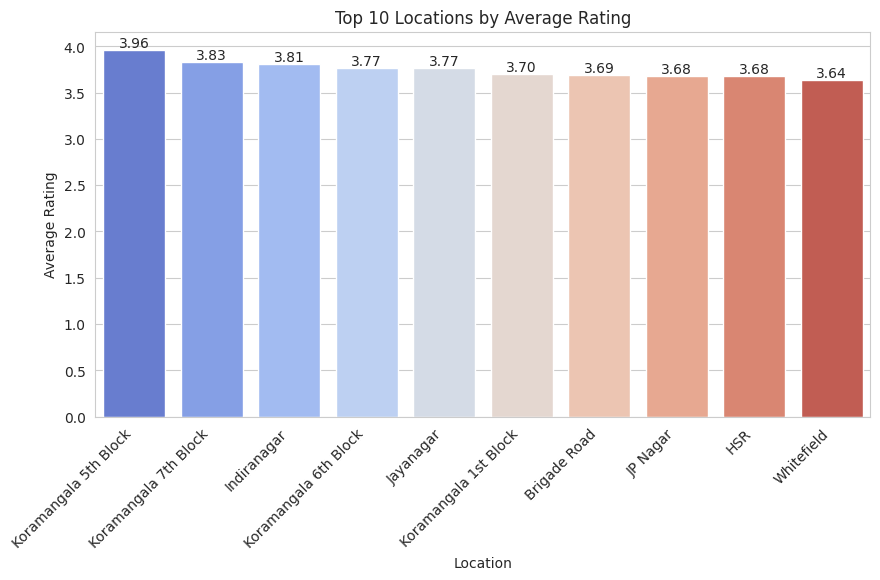

In [52]:
top_locs = df['location'].value_counts().head(15).index

loc_rating = (df[df['location'].isin(top_locs)].groupby('location')['rate'].mean().sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 5))

num = sns.barplot(x=loc_rating.index, y=loc_rating.values, hue=loc_rating.index,palette='coolwarm', legend=False)

for container in num.containers:
    num.bar_label(container, fmt='%.2f')

plt.title("Top 10 Locations by Average Rating")
plt.xlabel("Location")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.show()

#### Information Derived
- Koramangala 5th Block: 3.96 — highest average rating among top 10 locations by count.
- Koramangala 7th Block: 3.83 | Indiranagar: 3.81 | Koramangala 6th Block: 3.77 | Jayanagar: 3.77.
- Koramangala 1st Block: 3.70 | Brigade Road: 3.69 | JP Nagar: 3.68 | HSR: 3.68 | Whitefield: 3.64.
- Koramangala dominates the top spots — it is Bangalore's premium food and lifestyle hub.
- BTM (most restaurants: 5,114) does NOT appear in top 10 by rating —
  quantity does not equal quality.
- Business insight: Opening in Koramangala or Indiranagar gives a better chance
  of high ratings than a high-density but lower-quality zone.

## Key Findings

In [53]:
findings = {
    "Total Restaurants": df.shape[0],
    "Total Locations": df['location'].nunique(),
    "Online Order (Yes%)": f"{(df['online_order']=='Yes').mean()*100:.1f}%",
    "Table Booking (Yes%)": f"{(df['book_table']=='Yes').mean()*100:.1f}%",
    "Avg Rating (Online Order=Yes)": round(df[df['online_order']=='Yes']['rate'].mean(), 2),
    "Avg Rating (Online Order=No)": round(df[df['online_order']=='No']['rate'].mean(), 2),
    "Avg Rating (Table Booking=Yes)": round(df[df['book_table']=='Yes']['rate'].mean(), 2),
    "Avg Rating (Table Booking=No)": round(df[df['book_table']=='No']['rate'].mean(), 2),
    "Most Popular Location": df['location'].value_counts().idxmax(),
    "Most Popular Cuisine": df['cuisines'].value_counts().idxmax(),
    "Most Popular Rest Type": df['rest_type'].value_counts().idxmax(),
    "Most Reviewed Restaurant": df.drop_duplicates('name').sort_values('votes', ascending=False).iloc[0]['name'],
    "Most Expensive Restaurant": df.drop_duplicates('name').sort_values('approx_cost(for two people)', ascending=False).iloc[0]['name'],
}

summary_df = pd.DataFrame(findings.items(), columns=['Metric', 'Value'])
summary_df

,Metric,Value
0,Total Restaurants,51118
1,Total Locations,93
2,Online Order (Yes%),58.9%
3,Table Booking (Yes%),12.0%
4,Avg Rating (Online Order=Yes),3.71
5,Avg Rating (Online Order=No),3.67
6,Avg Rating (Table Booking=Yes),4.12
7,Avg Rating (Table Booking=No),3.64
8,Most Popular Location,BTM
9,Most Popular Cuisine,North Indian


## Project Conclusion

This project performed a complete Exploratory Data Analysis on the Zomato
Bangalore Restaurant Dataset containing 51,118 restaurant records across
93 locations.

The analysis began with thorough data cleaning — fixing the rating column
stored in '4.1/5' string format, removing commas from the cost column,
handling 28,074 missing values in dish_liked and 7,778 missing values in
the rate column using median imputation, and dropping irrelevant columns
(url and address).

Major findings from the analysis:

- Online Ordering is the norm — 58.9% of restaurants offer online ordering, reflecting Bangalore's strong food delivery culture. However online ordering has almost no impact on ratings — the difference is only 0.05 points (3.72 vs 3.67).

- Table Booking is the strongest quality signal — only 12% of restaurants offer table booking, but they average a rating of 4.12 compared to 3.64 for restaurants without it — a gap of 0.48 points, the largest factor-based rating difference in the entire dataset.

- Ratings are healthy and consistent — ratings range from 1.8 to 4.9 with a mean of 3.69 and median of 3.70, forming a symmetric bell curve peaking between 3.5-4.0.

- BTM dominates in quantity, Koramangala in quality — BTM has the most restaurants (5,114) but Koramangala 5th Block has the highest average rating (3.96). Quantity of restaurants does not equal quality.

- Quick Bites rule the market — 37.3% of all restaurants are Quick Bites confirming that Bangalore's food scene is driven by convenience and speed rather than fine dining.

- North Indian cuisine leads — despite being a South Indian city, North Indian cuisine (2,890 restaurants) tops the list, followed by North Indian + Chinese (2,370) — driven by Bangalore's large North Indian migrant workforce.

- Cost and quality are linked — restaurants above ₹1,500 for two consistently rate above 3.8. Budget restaurants under ₹300 show the widest rating variance. The correlation between cost and rating is 0.35.

- Brewery culture dominates engagement — 7 out of 10 most reviewed restaurants are brewpubs or bars. Byg Brewski Brewing Company leads with 16,345 votes and a 4.9 rating.

Overall, this analysis provided actionable insights into restaurant trends,
pricing behavior, customer preferences, and service availability in Bangalore
— demonstrating how data analysis can guide real business decisions in the
food and beverage industry.


## Key Business Insights

1. Table Booking = Higher Ratings
Restaurants offering table booking average 4.12 rating vs 3.64 without it - a gap of 0.48 points. Investing in the full dine-in experience drives significantly higher customer satisfaction.

2. Online Ordering Does Not Guarantee Better Ratings
Despite 58.9% of restaurants offering online ordering, the rating difference is only 0.05 points (3.72 vs 3.67). Online ordering improves reach, not necessarily customer satisfaction.

3. Location Quality Matters More Than Location Popularity
BTM has the most restaurants (5,114) but average ratings are lower than Koramangala, which has fewer restaurants but a higher average rating of 3.96. A premium location builds better brand perception.

4. Premium Pricing Signals Premium Quality
The correlation between cost and rating is 0.35. All top 10 most expensive restaurants (₹4,000–₹6,000 for two) are luxury hotel restaurants with an average rating of 4.24 — proving that price acts as a quality filter.

5. Experience-Driven Restaurants Outperform Delivery-Only Ones
Casual Dining + Bar type averages 4.05 rating while Takeaway & Delivery averages only 3.58. The more a restaurant invests in the dining experience, the higher its customer rating.

6. Popularity and Quality Go Hand in Hand
Votes and rating have a correlation of 0.42. Restaurants with 1,000+ votes almost never fall below 3.5 — sustained customer engagement over time filters out low-quality restaurants naturally.

7. North Indian Cuisine is the Market Leader
North Indian cuisine (2,890 restaurants) leads the market despite Bangalore
being a South Indian city — a direct result of the large migrant tech workforce. Entrepreneurs targeting Bangalore should consider this demand.

8. Budget Segment is Unpredictable
 Restaurants under ₹300 for two show the widest rating variance (2.0 to 4.5). Quality is least consistent and most unpredictable at the budget end of the market — making differentiation critical for budget restaurants.